## Step 1-2: Library Import, Configuration, and Data Loading
This section imports necessary libraries for data processing, machine learning, and visualization. It sets a random seed for reproducibility and loads four datasets: Bitcoin kline data with factors, on-chain metrics, sentiment indicators (Fear & Greed Index), and derivatives market data.

In [61]:
# ==========================================
# STEP 1: Import Libraries and Configuration
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("="*60)
print("PROJECT 2: Bitcoin Trading Strategy")
print("="*60)
print(f"Random Seed: {RANDOM_SEED}\n")

# ==========================================
# STEP 2: Load Data
# ==========================================
DATA_DIR = './data'

print("Loading data...")
# Load Bitcoin 4-hour kline data with technical factors
df_klines = pd.read_csv(f'{DATA_DIR}/BTCUSDT_4h_klines_with_factors.csv')
# Load on-chain metrics data
df_onchain = pd.read_csv(f'{DATA_DIR}/bitcoin_onchain_data_4h.csv')
# Load sentiment index data (Fear & Greed Index)
df_sentiment = pd.read_csv(f'{DATA_DIR}/bitcoin_fear_greed_index_4h.csv')
# Load derivatives market data
df_derivatives = pd.read_csv(f'{DATA_DIR}/bitcoin_derivatives_comprehensive_4h.csv')

print("✓ Data loaded successfully!\n")

# Display basic data information
print("Data shapes:")
print(f"  Klines: {df_klines.shape}")
print(f"  OnChain: {df_onchain.shape}")
print(f"  Sentiment: {df_sentiment.shape}")
print(f"  Derivatives: {df_derivatives.shape}")

print("\nKlines columns (first 10):")
print(df_klines.columns.tolist()[:10])

print("\nKlines sample (first 3 rows, first 5 columns):")
print(df_klines.iloc[:3, :5])

PROJECT 2: Bitcoin Trading Strategy
Random Seed: 42

Loading data...
✓ Data loaded successfully!

Data shapes:
  Klines: (17999, 90)
  OnChain: (10945, 6)
  Sentiment: (17011, 3)
  Derivatives: (19372, 6)

Klines columns (first 10):
['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume']

Klines sample (first 3 rows, first 5 columns):
             open_time     open     high      low    close
0  2017-08-17 04:00:00  4261.48  4349.99  4261.32  4349.99
1  2017-08-17 08:00:00  4333.32  4485.39  4333.32  4427.30
2  2017-08-17 12:00:00  4436.06  4485.39  4333.42  4352.34


## Step 3-4: Timestamp Processing and Label Creation
This section converts timestamps to datetime format across all datasets and creates the prediction target. The label identifies whether Bitcoin price will rise by 3% or more within the next week (42 periods of 4-hour intervals). Importantly, the last 42 rows are removed since they lack future data for label calculation, preventing data leakage.

In [62]:
# ==========================================
# STEP 3: Process Timestamps
# ==========================================
print("\n" + "="*60)
print("STEP 3: Processing Timestamps")
print("="*60)

# Convert klines time to datetime
df_klines['timestamp'] = pd.to_datetime(df_klines['open_time'], format='mixed')

# Process timestamps for other datasets
for name, df in [('OnChain', df_onchain), 
                  ('Sentiment', df_sentiment), 
                  ('Derivatives', df_derivatives)]:
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
    else:
        # Use the first column as timestamp
        df['timestamp'] = pd.to_datetime(df[df.columns[0]], format='mixed')
    
    # Remove Unnamed columns
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)

print("✓ Timestamps converted")

# Display time ranges
print("\nTimestamp ranges:")
print(f"  Klines: {df_klines['timestamp'].min()} to {df_klines['timestamp'].max()}")
print(f"  OnChain: {df_onchain['timestamp'].min()} to {df_onchain['timestamp'].max()}")
print(f"  Sentiment: {df_sentiment['timestamp'].min()} to {df_sentiment['timestamp'].max()}")
print(f"  Derivatives: {df_derivatives['timestamp'].min()} to {df_derivatives['timestamp'].max()}")

# ==========================================
# STEP 4: Create Label (Prediction Target) - FIXED VERSION
# ==========================================
print("\n" + "="*60)
print("STEP 4: Creating Label (FIXED)")
print("="*60)

# Define parameters
LOOK_FORWARD_PERIODS = 1
TARGET_RETURN = 0

print(f"Parameter settings:")
print(f"  Look-forward window: {LOOK_FORWARD_PERIODS} 4-hour periods")
print(f"  Target return: {TARGET_RETURN*100}%")

# Calculate cumulative return for the next week
def calculate_forward_return(close_prices, periods):
    """Calculate cumulative return for the next N periods"""
    forward_returns = []
    
    for i in range(len(close_prices)):
        if i + periods < len(close_prices):
            # Cumulative return for the next N periods
            future_return = (close_prices[i + periods] - close_prices[i]) / close_prices[i]
            forward_returns.append(future_return)
        else:
            # Insufficient future data available
            forward_returns.append(np.nan)
    
    return np.array(forward_returns)

# Calculate on the original klines data
print("\nCalculating next-week returns...")
df_klines['future_1week_return'] = calculate_forward_return(
    df_klines['close'].values, 
    LOOK_FORWARD_PERIODS
)

# Create binary classification label
df_klines['will_rise'] = (df_klines['future_1week_return'] > TARGET_RETURN).astype(int)

original_len = len(df_klines)
df_klines = df_klines.iloc[:-LOOK_FORWARD_PERIODS].copy()
print(f"  Original data: {original_len} rows")
print(f"  Usable data: {len(df_klines)} rows")
print(f"  Removed: {original_len - len(df_klines)} rows")

print("\n✓ Label creation completed")

# Label statistics
valid_labels = df_klines['will_rise'].notna()
n_positive = df_klines.loc[valid_labels, 'will_rise'].sum()
n_total = valid_labels.sum()

print("\nLabel statistics:")
print(f"  Total samples: {n_total}")
print(f"  Samples with rise: {n_positive} ({n_positive/n_total*100:.1f}%)")
print(f"  Samples without rise: {n_total - n_positive} ({(n_total-n_positive)/n_total*100:.1f}%)")

print("\nData sample:")
print(df_klines[['timestamp', 'close', 'future_1week_return', 'will_rise']].head(10))


STEP 3: Processing Timestamps
✓ Timestamps converted

Timestamp ranges:
  Klines: 2017-08-17 04:00:00 to 2025-11-05 12:00:00
  OnChain: 2020-11-06 00:00:00 to 2025-11-04 00:00:00
  Sentiment: 2018-02-01 00:00:00 to 2025-11-06 00:00:00
  Derivatives: 2017-01-01 00:00:00 to 2025-11-05 22:01:22.195272

STEP 4: Creating Label (FIXED)
Parameter settings:
  Look-forward window: 1 4-hour periods
  Target return: 0%

Calculating next-week returns...
  Original data: 17999 rows
  Usable data: 17998 rows
  Removed: 1 rows

✓ Label creation completed

Label statistics:
  Total samples: 17998
  Samples with rise: 9257 (51.4%)
  Samples without rise: 8741 (48.6%)

Data sample:
            timestamp    close  future_1week_return  will_rise
0 2017-08-17 04:00:00  4349.99             0.017772          1
1 2017-08-17 08:00:00  4427.30            -0.016931          0
2 2017-08-17 12:00:00  4352.34            -0.006229          0
3 2017-08-17 16:00:00  4325.23            -0.009283          0
4 2017-08-1

## Step 5-6: Data Merging and Feature Matrix Preparation
This section merges all data sources (on-chain, sentiment, and derivatives) with the klines data using timestamp as the key. It then prepares the feature matrix by excluding non-feature columns (timestamps, labels, raw prices), filtering for numeric features only, and handling missing values through row removal and forward/backward filling. The result is a clean dataset ready for model training.

In [63]:
# ==========================================
# STEP 5: Merge All Data Sources
# ==========================================
print("\n" + "="*60)
print("STEP 5: Merge All Data Sources")
print("="*60)

# Start with klines as base, merge other datasets
df_merged = df_klines.copy()

# Merge on-chain data
print("\nMerging on-chain data...")
df_onchain_clean = df_onchain.drop_duplicates(subset=['timestamp']).copy()
df_merged = pd.merge(df_merged, df_onchain_clean, on='timestamp', how='left', suffixes=('', '_onchain'))
print(f"  Shape after merge: {df_merged.shape}")

# Merge sentiment data
print("Merging sentiment data...")
df_sentiment_clean = df_sentiment.drop_duplicates(subset=['timestamp']).copy()
df_merged = pd.merge(df_merged, df_sentiment_clean, on='timestamp', how='left', suffixes=('', '_sentiment'))
print(f"  Shape after merge: {df_merged.shape}")

# Merge derivatives data
print("Merging derivatives data...")
df_derivatives_clean = df_derivatives.drop_duplicates(subset=['timestamp']).copy()
df_merged = pd.merge(df_merged, df_derivatives_clean, on='timestamp', how='left', suffixes=('', '_derivatives'))
print(f"  Shape after merge: {df_merged.shape}")

print(f"\n✓ Data merge completed")
print(f"  Final shape: {df_merged.shape}")

# ==========================================
# STEP 6: Prepare Feature Matrix
# ==========================================
print("\n" + "="*60)
print("STEP 6: Prepare Feature Matrix")
print("="*60)

# Exclude columns that cannot be used as features
exclude_cols = [
    'timestamp', 'open_time', 'close_time',  # Time columns
    'future_1week_return', 'will_rise',  # Label columns
    'close', 'open', 'high', 'low',  # Raw prices (avoid direct use)
]

# Select all potential feature columns
potential_features = [col for col in df_merged.columns if col not in exclude_cols]

print(f"\nPotential feature count: {len(potential_features)}")

# ⭐ Check data types, keep only numeric features
print("\nChecking feature data types...")
numeric_features = []
non_numeric_features = []

for col in potential_features:
    if df_merged[col].dtype in ['int64', 'float64', 'int32', 'float32']:
        numeric_features.append(col)
    else:
        non_numeric_features.append(col)
        print(f"  ⚠️  Non-numeric feature: {col} (type: {df_merged[col].dtype})")

print(f"\n✓ Numeric features: {len(numeric_features)}")
print(f"⚠️  Non-numeric features: {len(non_numeric_features)}")

# Use only numeric features
feature_cols = numeric_features

print(f"\nFinal feature count: {len(feature_cols)}")
print(f"\nFirst 20 features:")
for i, col in enumerate(feature_cols[:20], 1):
    print(f"  {i:2d}. {col}")

print(f"\nTotal features: {len(feature_cols)}")

# Check for missing values
print("\nChecking missing values...")
missing_counts = df_merged[feature_cols].isnull().sum()
missing_features = missing_counts[missing_counts > 0].sort_values(ascending=False)

if len(missing_features) > 0:
    print(f"  Features with missing values: {len(missing_features)}")
    print(f"\n  Top 10 features with most missing values:")
    for col, count in missing_features.head(10).items():
        pct = count / len(df_merged) * 100
        print(f"    {col}: {count} ({pct:.1f}%)")
else:
    print("  ✓ No missing values")

# Remove rows with too many missing values
print("\nHandling missing values...")
threshold = len(feature_cols) * 0.5
df_clean = df_merged.dropna(subset=feature_cols, thresh=int(threshold))
print(f"  Original rows: {len(df_merged)}")
print(f"  Rows with excessive missing values removed: {len(df_merged) - len(df_clean)}")
print(f"  Rows retained: {len(df_clean)}")

# Fill remaining missing values with forward/backward fill
df_clean[feature_cols] = df_clean[feature_cols].fillna(method='ffill')
df_clean[feature_cols] = df_clean[feature_cols].fillna(method='bfill')
df_clean[feature_cols] = df_clean[feature_cols].fillna(0)

print(f"\n✓ Missing value handling completed")
print(f"  Final data shape: {df_clean.shape}")

# Verify no missing values remain
remaining_missing = df_clean[feature_cols].isnull().sum().sum()
print(f"  Remaining missing values: {remaining_missing}")

# ⭐ Verify all features are numeric
print("\nVerifying feature data types...")
non_numeric_check = []
for col in feature_cols:
    if df_clean[col].dtype not in ['int64', 'float64', 'int32', 'float32']:
        non_numeric_check.append(col)

if len(non_numeric_check) > 0:
    print(f"  ⚠️  Still have non-numeric features: {non_numeric_check}")
else:
    print(f"  ✓ All features are numeric")

# Verify labels have no missing values
label_missing = df_clean['will_rise'].isnull().sum()
print(f"  Label missing values: {label_missing}")

print("\nData preparation complete!")


STEP 5: Merge All Data Sources

Merging on-chain data...
  Shape after merge: (17998, 98)
Merging sentiment data...
  Shape after merge: (17998, 100)
Merging derivatives data...
  Shape after merge: (17998, 105)

✓ Data merge completed
  Final shape: (17998, 105)

STEP 6: Prepare Feature Matrix

Potential feature count: 96

Checking feature data types...
  ⚠️  Non-numeric feature: value_classification (type: object)

✓ Numeric features: 95
⚠️  Non-numeric features: 1

Final feature count: 95

First 20 features:
   1. volume
   2. quote_asset_volume
   3. number_of_trades
   4. taker_buy_base_asset_volume
   5. taker_buy_quote_asset_volume
   6. ignore
   7. returns_1h
   8. returns_4h
   9. returns_8h
  10. returns_24h
  11. returns_7d
  12. high_low_ratio
  13. close_position
  14. price_zscore_20
  15. price_momentum_5
  16. price_momentum_10
  17. MA_5
  18. MA_10
  19. MA_20
  20. MA_50

Total features: 95

Checking missing values...
  Features with missing values: 67

  Top 10 fe

## Step 7: Outlier Detection and Data Cleaning
This section identifies and handles extreme values, infinite values, and NaN in the feature set. Features with extreme values (|value| > 1e6) are removed to prevent model instability. Any remaining Inf values are converted to NaN and then filled using forward/backward fill methods. Final validation ensures the dataset is clean and ready for modeling.

In [64]:
# ==========================================
# STEP 7: Outlier Detection and Cleaning
# ==========================================
print("\n" + "="*60)
print("STEP 7: Outlier Detection and Cleaning")
print("="*60)

# Check statistical information for each feature
print("\nChecking feature statistical ranges...")
feature_stats = df_clean[feature_cols].describe()

# Identify features with extreme values
print("\nChecking extreme values (|max| > 1e6 or |min| > 1e6):")
extreme_features = []
for col in feature_cols:
    max_val = df_clean[col].max()
    min_val = df_clean[col].min()
    if abs(max_val) > 1e6 or abs(min_val) > 1e6:
        extreme_features.append(col)
        print(f"  {col}: min={min_val:.2e}, max={max_val:.2e}")

if len(extreme_features) > 0:
    print(f"\nFound {len(extreme_features)} features with extreme values")
    
    # Check distribution of these features across train/test periods
    print("\nChecking extreme value distribution in train/test sets:")
    
    n_train_split = int(len(df_clean) * 0.6)
    n_val_split = int(len(df_clean) * 0.8)
    
    for col in extreme_features[:5]:  # Show first 5 only
        train_max = df_clean[col].iloc[:n_train_split].max()
        test_max = df_clean[col].iloc[n_val_split:].max()
        print(f"  {col}:")
        print(f"    Train max: {train_max:.2e}")
        print(f"    Test max: {test_max:.2e}")
    
    # Solution: Remove features with extreme values
    print(f"\n⚠️  Recommendation: Remove features with extreme values")
    print(f"  Removing {len(extreme_features)} features")
    
    feature_cols_clean = [col for col in feature_cols if col not in extreme_features]
    print(f"  Retained features: {len(feature_cols_clean)} (from {len(feature_cols)})")
    
    # Update feature_cols
    feature_cols = feature_cols_clean
    
else:
    print("✓ No extreme values found")

# Additional check: Inf and NaN
print("\nChecking for Inf and NaN...")
inf_counts = np.isinf(df_clean[feature_cols].values).sum(axis=0)
nan_counts = np.isnan(df_clean[feature_cols].values).sum(axis=0)

features_with_inf = [feature_cols[i] for i in range(len(feature_cols)) if inf_counts[i] > 0]
features_with_nan = [feature_cols[i] for i in range(len(feature_cols)) if nan_counts[i] > 0]

if len(features_with_inf) > 0:
    print(f"  ⚠️  Features with Inf: {features_with_inf}")
    # Replace Inf with NaN, then fill
    for col in features_with_inf:
        df_clean[col] = df_clean[col].replace([np.inf, -np.inf], np.nan)
    print(f"  Converted Inf to NaN")

if len(features_with_nan) > 0:
    print(f"  ⚠️  Features with NaN: {len(features_with_nan)}")
    # Re-fill NaN values
    df_clean[feature_cols] = df_clean[feature_cols].fillna(method='ffill')
    df_clean[feature_cols] = df_clean[feature_cols].fillna(method='bfill')
    df_clean[feature_cols] = df_clean[feature_cols].fillna(0)
    print(f"  Re-filled NaN values")

if len(features_with_inf) == 0 and len(features_with_nan) == 0:
    print("  ✓ No Inf or NaN found")

# Final validation
print("\nFinal data quality check:")
print(f"  Feature count: {len(feature_cols)}")
print(f"  Sample count: {len(df_clean)}")
print(f"  Missing values: {df_clean[feature_cols].isnull().sum().sum()}")
print(f"  Inf values: {np.isinf(df_clean[feature_cols].values).sum()}")

# Display final retained features
print(f"\nFinal feature list (first 30):")
for i, col in enumerate(feature_cols[:30], 1):
    print(f"  {i:2d}. {col}")

if len(feature_cols) > 30:
    print(f"  ... plus {len(feature_cols)-30} more features")

print("\n✓ Data cleaning completed!")


STEP 7: Outlier Detection and Cleaning

Checking feature statistical ranges...

Checking extreme values (|max| > 1e6 or |min| > 1e6):
  quote_asset_volume: min=0.00e+00, max=5.46e+09
  number_of_trades: min=0.00e+00, max=6.09e+06
  taker_buy_quote_asset_volume: min=0.00e+00, max=2.75e+09
  obv: min=-9.58e+05, max=3.38e+06
  obv_ma_20: min=-8.52e+05, max=3.37e+06
  price_volume_divergence: min=-2.32e+07, max=1.17e+07
  hash_rate: min=5.85e+07, max=1.31e+09
  mining_difficulty: min=1.37e+13, max=1.56e+14
  open_interest_total: min=2.57e+06, max=2.92e+07

Found 9 features with extreme values

Checking extreme value distribution in train/test sets:
  quote_asset_volume:
    Train max: 4.74e+09
    Test max: 4.67e+09
  number_of_trades:
    Train max: 2.18e+06
    Test max: 6.09e+06
  taker_buy_quote_asset_volume:
    Train max: 2.37e+09
    Test max: 2.26e+09
  obv:
    Train max: 2.27e+06
    Test max: 3.38e+06
  obv_ma_20:
    Train max: 2.25e+06
    Test max: 3.37e+06

⚠️  Recommendati

In [65]:
train_portion = 0.7
val_portion = 0.2


## Step 8: Deep Diagnosis - Identify Problem Features
This section performs a multi-round diagnosis to identify problematic features that may cause model instability. It checks for features where test set values are significantly larger than training set values (>100x ratio), features with extreme absolute values (>1e6), and displays the top extreme-valued features in the test set. Problem features are removed to ensure model robustness.

In [66]:
# ==========================================
# STEP 8: Deep Diagnosis - Find Problem Features
# ==========================================
print("\n" + "="*60)
print("STEP 8: Deep Diagnosis - Find Problem Features")
print("="*60)

# Split data by time periods for checking
n_total = len(df_clean)
n_train = int(n_total * train_portion)
n_val = int(n_total * val_portion)

train_split = df_clean.iloc[:n_train]
val_split = df_clean.iloc[n_train:n_train+n_val]
test_split = df_clean.iloc[n_train+n_val:]

print(f"Checking feature statistics across different periods...")
print(f"\nLooking for features with anomalies in test set:\n")

problem_features = []

for col in feature_cols:
    train_max = train_split[col].abs().max()
    test_max = test_split[col].abs().max()
    
    # Flag if test max is much larger than train max (>100x)
    if test_max > train_max * 100 and train_max > 0:
        problem_features.append(col)
        print(f"⚠️  {col}:")
        print(f"    Train max: {train_max:.2e}")
        print(f"    Test max: {test_max:.2e}")
        print(f"    Ratio: {test_max/train_max:.1f}x")
        print()

if len(problem_features) == 0:
    print("Round 1: No obvious issues found")
    
    # Round 2: Check for features with large absolute values
    print("\nRound 2: Finding features with absolute value > 1e6 in test set:\n")
    for col in feature_cols:
        test_max_abs = test_split[col].abs().max()
        if test_max_abs > 1e6:
            problem_features.append(col)
            print(f"⚠️  {col}:")
            print(f"    Train range: [{train_split[col].min():.2e}, {train_split[col].max():.2e}]")
            print(f"    Test range: [{test_split[col].min():.2e}, {test_split[col].max():.2e}]")
            print()

if len(problem_features) > 0:
    print(f"\nFound {len(problem_features)} problem features")
    print(f"Recommend removing these features: {problem_features}")
    
    # Remove problem features
    feature_cols_final = [col for col in feature_cols if col not in problem_features]
    
    print(f"\nUpdating feature list:")
    print(f"  Removed: {len(problem_features)} features")
    print(f"  Retained: {len(feature_cols_final)} features")
    
    # Update global variable
    feature_cols = feature_cols_final
    
    print("\n✓ Feature cleaning completed")
else:
    print("\n✓ No problem features found (unusual, continuing checks)")
    
    # Round 3: Direct check of test set statistics
    print("\nRound 3: Extreme values across all features in test set:\n")
    test_extremes = []
    for col in feature_cols:
        max_val = test_split[col].abs().max()
        if max_val > 1e5:  # Lower threshold
            test_extremes.append((col, max_val))
    
    test_extremes.sort(key=lambda x: x[1], reverse=True)
    
    print("Top 10 features with largest absolute values in test set:")
    for col, val in test_extremes[:10]:
        print(f"  {col}: {val:.2e}")

print(f"\nFinal feature count: {len(feature_cols)}")


STEP 8: Deep Diagnosis - Find Problem Features
Checking feature statistics across different periods...

Looking for features with anomalies in test set:

⚠️  funding_rate_avg:
    Train max: 4.02e-13
    Test max: 1.09e-04
    Ratio: 271853778.2x


Found 1 problem features
Recommend removing these features: ['funding_rate_avg']

Updating feature list:
  Removed: 1 features
  Retained: 85 features

✓ Feature cleaning completed

Final feature count: 85


## Step 9-10: Time Series Split and Feature Scaling
This section splits the data chronologically into train (60%), validation (20%), and test (20%) sets without shuffling to preserve temporal order. Features are then standardized using StandardScaler, where the scaler is fitted only on training data and applied to validation and test sets to prevent data leakage. This ensures the model never sees future information during training.

In [67]:
# ==========================================
# STEP 9: Time Series Split (Train/Val/Test)
# ==========================================
print("\n" + "="*60)
print("STEP 8: Time Series Split (Train/Val/Test)")
print("="*60)

# Critical: Split by time order, no random shuffling

n_total = len(df_clean)
n_train = int(n_total * train_portion)
n_val = int(n_total * val_portion)

print(f"\nData split strategy:")
print(f"  Total data: {n_total}")
print(f"  Train set: First {train_portion * 100}% = {n_train} rows")
print(f"  Val set: Middle {val_portion * 100}% = {n_val} rows")
print(f"  Test set: Last {(1-train_portion-val_portion) * 100}% = {n_total - n_train - n_val} rows")

# Split by chronological order
train_data = df_clean.iloc[:n_train].copy()
val_data = df_clean.iloc[n_train:n_train+n_val].copy()
test_data = df_clean.iloc[n_train+n_val:].copy()

print(f"\nTime ranges:")
print(f"  Train: {train_data['timestamp'].min()} to {train_data['timestamp'].max()}")
print(f"  Val: {val_data['timestamp'].min()} to {val_data['timestamp'].max()}")
print(f"  Test: {test_data['timestamp'].min()} to {test_data['timestamp'].max()}")

# Prepare features and labels
X_train = train_data[feature_cols].values
y_train = train_data['will_rise'].values

X_val = val_data[feature_cols].values
y_val = val_data['will_rise'].values

X_test = test_data[feature_cols].values
y_test = test_data['will_rise'].values

print(f"\nFeature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  X_test: {X_test.shape}")

print(f"\nLabel distribution:")
print(f"  Train - Positive samples: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"  Val - Positive samples: {y_val.sum()} ({y_val.mean()*100:.1f}%)")
print(f"  Test - Positive samples: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

# ==========================================
# STEP 10: Feature Scaling (Critical: Fit only on train)
# ==========================================
print("\n" + "="*60)
print("STEP 10: Feature Scaling")
print("="*60)

print("⭐ Key principle: Compute mean and std only from training set")

# Create scaler and fit only on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transform val and test sets using train statistics
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\nScaling completed:")
print(f"  Train mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}")
print(f"  Val mean: {X_val_scaled.mean():.6f}, std: {X_val_scaled.std():.6f}")
print(f"  Test mean: {X_test_scaled.mean():.6f}, std: {X_test_scaled.std():.6f}")

print("\n✓ Data preparation complete! Ready for model training...")

# Save key information for later use
print("\n" + "="*60)
print("Data Preparation Summary")
print("="*60)
print(f"Feature count: {len(feature_cols)}")
print(f"Train samples: {len(X_train)} ({len(X_train)/n_total*100:.1f}%)")
print(f"Val samples: {len(X_val)} ({len(X_val)/n_total*100:.1f}%)")
print(f"Test samples: {len(X_test)} ({len(X_test)/n_total*100:.1f}%)")
print(f"Prediction horizon: {LOOK_FORWARD_PERIODS} 4-hour periods (approx {LOOK_FORWARD_PERIODS*4/24:.1f} days)")
print("="*60)


STEP 8: Time Series Split (Train/Val/Test)

Data split strategy:
  Total data: 17993
  Train set: First 70.0% = 12595 rows
  Val set: Middle 20.0% = 3598 rows
  Test set: Last 10.000000000000004% = 1800 rows

Time ranges:
  Train: 2017-08-18 00:00:00 to 2023-05-20 16:00:00
  Val: 2023-05-20 20:00:00 to 2025-01-09 08:00:00
  Test: 2025-01-09 12:00:00 to 2025-11-05 08:00:00

Feature matrix shapes:
  X_train: (12595, 85)
  X_val: (3598, 85)
  X_test: (1800, 85)

Label distribution:
  Train - Positive samples: 6474 (51.4%)
  Val - Positive samples: 1876 (52.1%)
  Test - Positive samples: 905 (50.3%)

STEP 10: Feature Scaling
⭐ Key principle: Compute mean and std only from training set

Scaling completed:
  Train mean: -0.000000, std: 0.994100
  Val mean: 0.347731, std: 1.539591
  Test mean: 0.764163, std: 2.127101

✓ Data preparation complete! Ready for model training...

Data Preparation Summary
Feature count: 85
Train samples: 12595 (70.0%)
Val samples: 3598 (20.0%)
Test samples: 1800 (

## Step 11: Model Training and Evaluation
This section trains Logistic Regression models with both L1 (Lasso) and L2 (Ridge) regularization, testing various C values to find the optimal regularization strength. The best model is selected based on validation accuracy. Detailed evaluation includes accuracy scores, classification report, confusion matrix, prediction probability distribution, and top 10 most important features ranked by absolute coefficient values.

In [68]:
# ==========================================
# STEP 11: Hyperparameter Optimization + Model Training
# ==========================================
print("\n" + "="*60)
print("STEP 11: Hyperparameter Optimization")
print("="*60)

from sklearn.model_selection import GridSearchCV

# 参数网格
param_grid = {
    "penalty": ["l1", "l2"],
    "C": [0.01, 0.1, 1, 5, 10, 50, 100],
    "solver": ["liblinear", "lbfgs"],  # liblinear 兼容 L1/L2, lbfgs 兼容 L2
}

log_reg = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_SEED
)

grid = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring="accuracy",   # 如需 F1/AUC 可改
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("\nRunning GridSearchCV ...")
grid.fit(X_train_scaled, y_train)

print("\n" + "-"*60)
print("Best Hyperparameters:")
print(grid.best_params_)
print(f"Best CV Score: {grid.best_score_:.4f}")

# 使用最佳模型
final_model = grid.best_estimator_

# ============================
# Evaluate on Train/Validation
# ============================
print("\n" + "="*60)
print("Final Model Evaluation")
print("="*60)

train_score = final_model.score(X_train_scaled, y_train)
val_score = final_model.score(X_val_scaled, y_val)

print(f"\nAccuracy:")
print(f"  Train: {train_score:.4f}")
print(f"  Val:   {val_score:.4f}")

# Predictions
y_train_pred = final_model.predict(X_train_scaled)
y_val_pred = final_model.predict(X_val_scaled)
y_val_proba = final_model.predict_proba(X_val_scaled)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix

print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred,
                            target_names=['No 3% Rise', '3% Rise'],
                            digits=4))

cm = confusion_matrix(y_val, y_val_pred)
print("Validation Confusion Matrix:")
print(f"              Pred:No Rise  Pred:Rise")
print(f"True:No Rise    {cm[0,0]:>8d}    {cm[0,1]:>8d}")
print(f"True:Rise       {cm[1,0]:>8d}    {cm[1,1]:>8d}")

print("\nPrediction Probability Distribution:")
print(f"  Min: {y_val_proba.min():.4f}")
print(f"  25th percentile: {np.percentile(y_val_proba, 25):.4f}")
print(f"  Median: {np.percentile(y_val_proba, 50):.4f}")
print(f"  75th percentile: {np.percentile(y_val_proba, 75):.4f}")
print(f"  Max: {y_val_proba.max():.4f}")

# ==========================================
# Feature Importance (L1/L2 都可打印)
# ==========================================
print("\nTop 10 Most Important Features:")

feature_importance = np.abs(final_model.coef_[0])
top_indices = np.argsort(feature_importance)[-10:][::-1]

for i, idx in enumerate(top_indices, 1):
    print(f"  {i:2d}. {feature_cols[idx]:<30s} "
          f"(|coef|: {feature_importance[idx]:>8.4f}, "
          f"coef: {final_model.coef_[0][idx]:>8.4f})")

print("\n✓ Model training and evaluation completed with GridSearchCV!")


STEP 11: Hyperparameter Optimization

Running GridSearchCV ...
Fitting 5 folds for each of 28 candidates, totalling 140 fits

------------------------------------------------------------
Best Hyperparameters:
{'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Score: 0.5553

Final Model Evaluation

Accuracy:
  Train: 0.5585
  Val:   0.5497

Validation Classification Report:
              precision    recall  f1-score   support

  No 3% Rise     0.5280    0.5587    0.5429      1722
     3% Rise     0.5721    0.5416    0.5564      1876

    accuracy                         0.5497      3598
   macro avg     0.5500    0.5501    0.5496      3598
weighted avg     0.5510    0.5497    0.5499      3598

Validation Confusion Matrix:
              Pred:No Rise  Pred:Rise
True:No Rise         962         760
True:Rise            860        1016

Prediction Probability Distribution:
  Min: 0.3870
  25th percentile: 0.4574
  Median: 0.4989
  75th percentile: 0.5420
  Max: 0.6132

Top 10 Mos

## Step 12: Trading Strategy - Probability Threshold Optimization
This section optimizes the trading strategy by testing different probability thresholds (0.1 to 0.5) on the validation set to maximize Sharpe Ratio. For each threshold, it calculates actual future returns, generates trading signals, accounts for transaction costs, and computes performance metrics including total return, annualized return, and Sharpe Ratio. The optimal threshold is selected and compared against a Buy & Hold benchmark strategy.

In [69]:
# ==========================================
# STEP 12: Trading Strategy - Probability Threshold Optimization
# ==========================================
print("\n" + "="*60)
print("STEP 12: Trading Strategy - Probability Threshold Optimization")
print("="*60)

print("\nStrategy design:")
print("  - Don't use fixed 0.5 threshold")
print("  - Find optimal probability threshold on validation set")
print("  - Objective: Maximize Sharpe Ratio")

# Get validation set prediction probabilities
y_val_proba = final_model.predict_proba(X_val_scaled)[:, 1]

# Calculate actual future returns for validation set
print("\nCalculating validation set actual returns...")
val_actual_returns = []
for i in range(len(val_data)):
    idx = val_data.index[i]
    # Find position of this timestamp in df_clean
    pos_in_clean = df_clean.index.get_loc(idx)
    
    # Check if sufficient future data exists
    if pos_in_clean + 1 < len(df_clean):
        future_idx = df_clean.index[pos_in_clean + 1]
        current_price = df_clean.loc[idx, 'close']
        future_price = df_clean.loc[future_idx, 'close']
        actual_return = (future_price - current_price) / current_price
        val_actual_returns.append(actual_return)
    else:
        val_actual_returns.append(0.0)  # No future data, return is 0

val_actual_returns = np.array(val_actual_returns)
print(f"✓ Actual returns calculated")
print(f"  Sample count: {len(val_actual_returns)}")
print(f"  Mean return: {val_actual_returns.mean()*100:.2f}%")
print(f"  Return std dev: {val_actual_returns.std()*100:.2f}%")

# ==========================================
# Test Different Probability Thresholds
# ==========================================
print("\nTesting different probability thresholds on validation set:")
print("-"*80)
print(f"{'Threshold':<8} {'# Signals':<10} {'Total Ret%':<12} {'Annual Ret%':<12} {'Sharpe':<10}")
print("-"*80)
thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
best_sharpe = -999
best_threshold = 0.5
results = []

for threshold in thresholds:
    # Generate trading signals
    signals = (y_val_proba >= threshold).astype(int)
    n_signals = signals.sum()
    
    if n_signals == 0:
        continue
    
    # Calculate strategy returns (hold only when signal is 1)
    strategy_returns = signals * val_actual_returns
    
    # Total return
    total_return = np.prod(1+strategy_returns) - 1 
    
    # Annualized return (assume val set covers ~1.6 years)
    n_years = len(val_data) * 4 / (24 * 365.25)  # 4-hour data
    annual_return = total_return / n_years
    
    # Sharpe Ratio (using returns during active periods)
    active_returns = strategy_returns[signals == 1]
    if len(active_returns) > 1 and active_returns.std() > 0:
        # Annualized Sharpe (assume each trade holds for 7 days)
        n_trades_per_year = 365.25 / 7
        sharpe = (active_returns.mean() / active_returns.std()) * np.sqrt(n_trades_per_year)
    else:
        sharpe = 0
    
    results.append({
        'threshold': threshold,
        'n_signals': n_signals,
        'total_return': total_return,
        'annual_return': annual_return,
        'sharpe': sharpe
    })
    
    print(f"{threshold:<8.2f} {n_signals:<10d} {total_return*100:<12.2f} {annual_return*100:<12.2f} {sharpe:<10.2f}")
    
    if sharpe > best_sharpe:
        best_sharpe = sharpe
        best_threshold = threshold

print("-"*80)

if best_sharpe > 0:
    print(f"\n✓ Optimal probability threshold: {best_threshold} (Sharpe: {best_sharpe:.2f})")
else:
    print(f"\n⚠️  All thresholds have Sharpe ≤ 0, selecting threshold with most signals")
    # Select threshold that generates reasonable number of signals
    valid_results = [r for r in results if r['n_signals'] >= 10]
    if valid_results:
        best_result = max(valid_results, key=lambda x: x['total_return'])
        best_threshold = best_result['threshold']
        print(f"   Selected threshold: {best_threshold} (signals: {best_result['n_signals']})")
    else:
        best_threshold = 0.3
        print(f"   Using default threshold: {best_threshold}")

# ==========================================
# Buy & Hold Benchmark
# ==========================================
print("\n" + "="*60)
print("Benchmark Strategy: Buy & Hold")
print("="*60)
buy_hold_return = np.prod(1+val_actual_returns)-1
buy_hold_annual = buy_hold_return / n_years
buy_hold_sharpe = val_actual_returns.mean() / val_actual_returns.std() * np.sqrt(365.25 / 7) if val_actual_returns.std() > 0 else 0

print(f"Buy & Hold (validation set):")
print(f"  Total return: {buy_hold_return*100:.2f}%")
print(f"  Annualized return: {buy_hold_annual*100:.2f}%")
print(f"  Sharpe Ratio: {buy_hold_sharpe:.2f}")

print("\n✓ Validation set strategy optimization completed!")
print(f"\nNext step: Final backtest on test set using threshold {best_threshold}")


STEP 12: Trading Strategy - Probability Threshold Optimization

Strategy design:
  - Don't use fixed 0.5 threshold
  - Find optimal probability threshold on validation set
  - Objective: Maximize Sharpe Ratio

Calculating validation set actual returns...
✓ Actual returns calculated
  Sample count: 3598
  Mean return: 0.04%
  Return std dev: 0.99%

Testing different probability thresholds on validation set:
--------------------------------------------------------------------------------
Threshold # Signals  Total Ret%   Annual Ret%  Sharpe    
--------------------------------------------------------------------------------
0.10     3598       247.73       150.89       0.29      
0.15     3598       247.73       150.89       0.29      
0.20     3598       247.73       150.89       0.29      
0.25     3598       247.73       150.89       0.29      
0.30     3598       247.73       150.89       0.29      
0.35     3598       247.73       150.89       0.29      
0.40     3590       245.13 

## Step 13: Out-of-Sample Backtest on Test Set
This section performs the final backtest on the test set using the optimal threshold selected from validation. It calculates actual future returns, generates trading signals, and computes comprehensive performance metrics including total return, annualized return, Sharpe ratio, maximum drawdown, win rate, and trading costs. Results are compared against a Buy & Hold benchmark to evaluate the strategy's risk-adjusted performance.

In [70]:
# ==========================================
# STEP 13: Final Out-of-Sample Backtest (Test Set)
# ==========================================
print("\n" + "="*60)
print("STEP 13: OUT-OF-SAMPLE BACKTEST (Test Set)")
print("="*60)

print(f"\n⚠️  Critical reminder:")
print(f"  - This is the ONLY time we use the test set")
print(f"  - Using optimal threshold from validation: {best_threshold}")
print(f"  - Test period: 2024-03-10 to 2025-10-29")

# Get test set prediction probabilities
y_test_proba = final_model.predict_proba(X_test_scaled)[:, 1]

print(f"\nTest set prediction probability statistics:")
print(f"  Min: {y_test_proba.min():.4f}")
print(f"  25th percentile: {np.percentile(y_test_proba, 25):.4f}")
print(f"  Median: {np.percentile(y_test_proba, 50):.4f}")
print(f"  75th percentile: {np.percentile(y_test_proba, 75):.4f}")
print(f"  Max: {y_test_proba.max():.4f}")

# Calculate actual future returns for test set
print("\nCalculating test set actual returns...")
test_actual_returns = []

for i in range(len(test_data)):
    idx = test_data.index[i]
    pos_in_clean = df_clean.index.get_loc(idx)
    
    if pos_in_clean + 1 < len(df_clean):
        future_idx = df_clean.index[pos_in_clean + 1]
        current_price = df_clean.loc[idx, 'close']
        future_price = df_clean.loc[future_idx, 'close']
        actual_return = (future_price - current_price) / current_price
        test_actual_returns.append(actual_return)
    else:
        test_actual_returns.append(0.0)

test_actual_returns = np.array(test_actual_returns)

print(f"✓ Actual returns calculated")
print(f"  Sample count: {len(test_actual_returns)}")
print(f"  Mean return: {test_actual_returns.mean()*100:.2f}%")
print(f"  Return std dev: {test_actual_returns.std()*100:.2f}%")

# ==========================================
# Generate Trading Signals Using Optimal Threshold
# ==========================================
print(f"\nGenerating trading signals (threshold={best_threshold})...")
test_signals = (y_test_proba >= best_threshold).astype(int)

print(f"\nSignal statistics:")
print(f"  Long signals: {test_signals.sum()} ({test_signals.sum()/len(test_signals)*100:.1f}%)")
print(f"  No position: {len(test_signals) - test_signals.sum()} ({(1-test_signals.sum()/len(test_signals))*100:.1f}%)")

# ==========================================
# Calculate Strategy Performance
# ==========================================
print("\nCalculating strategy performance...")

# Strategy returns (hold only when signal = 1)
strategy_returns = test_signals * test_actual_returns

# Trading costs
n_trades_test = test_signals.sum() * 2  # Each signal = buy + sell

# Total returns
strategy_total_return = np.prod(1 + strategy_returns) - 1
buyhold_total_return = np.prod(1 + test_actual_returns) - 1

# Annualized returns
n_years_test = len(test_data) * 4 / (24 * 365.25)
strategy_annual_return = strategy_total_return / n_years_test
buyhold_annual_return = buyhold_total_return / n_years_test

# Sharpe Ratio
active_returns = strategy_returns[test_signals == 1]
if len(active_returns) > 1 and active_returns.std() > 0:
    n_trades_per_year = 365.25 / 7
    strategy_sharpe = (active_returns.mean() / active_returns.std()) * np.sqrt(n_trades_per_year)
else:
    strategy_sharpe = 0

buyhold_sharpe = (test_actual_returns.mean() / test_actual_returns.std()) * np.sqrt(n_trades_per_year) if test_actual_returns.std() > 0 else 0

# Maximum Drawdown
def calculate_max_drawdown(returns):
    cumulative = (1 + returns).cumprod()
    running_max = np.maximum.accumulate(cumulative)
    drawdown = (cumulative - running_max) / running_max
    return drawdown.min()

strategy_cumulative = np.concatenate([[0], strategy_returns])
buyhold_cumulative = test_actual_returns

strategy_max_dd = calculate_max_drawdown(strategy_cumulative)
buyhold_max_dd = calculate_max_drawdown(buyhold_cumulative)

# Win rate
if test_signals.sum() > 0:
    wins = np.sum((strategy_returns > 0) & (test_signals == 1))
    total_trades_made = test_signals.sum()
    win_rate = wins / total_trades_made
else:
    win_rate = 0

# ==========================================
# Output Final Results
# ==========================================
print("\n" + "="*60)
print("OUT-OF-SAMPLE FINAL RESULTS")
print("="*60)

print(f"\n{'Metric':<30} {'Strategy':<20} {'Buy & Hold':<20}")
print("-"*70)
print(f"{'Total Return':<30} {strategy_total_return*100:>18.2f}% {buyhold_total_return*100:>18.2f}%")
print(f"{'Annualized Return':<30} {strategy_annual_return*100:>18.2f}% {buyhold_annual_return*100:>18.2f}%")
print(f"{'Sharpe Ratio':<30} {strategy_sharpe:>18.2f} {buyhold_sharpe:>18.2f}")
print(f"{'Max Drawdown':<30} {strategy_max_dd*100:>18.2f}% {buyhold_max_dd*100:>18.2f}%")
print(f"{'Number of Trades':<30} {n_trades_test:>18d} {0:>18d}")
print("-"*70)

if test_signals.sum() > 0:
    print(f"{'Win Rate':<30} {win_rate*100:>18.2f}%")
    print(f"{'Avg Return per Trade':<30} {active_returns.mean()*100:>18.2f}%")
    print(f"{'Std Dev per Trade':<30} {active_returns.std()*100:>18.2f}%")

print("\n" + "="*60)
print("Test Period Performance")
print("="*60)
print(f"Test period: {test_data['timestamp'].min()} to {test_data['timestamp'].max()}")
print(f"Duration: {n_years_test:.2f} years")
print(f"Bitcoin price change:")
start_price = df_clean.loc[test_data.index[0], 'close']
end_price = df_clean.loc[test_data.index[-1], 'close']
print(f"  Start: ${start_price:,.0f}")
print(f"  End: ${end_price:,.0f}")
print(f"  Change: {(end_price/start_price - 1)*100:.2f}%")

print("\n✓ Test set backtest completed!")

# ==========================================
# Results Interpretation
# ==========================================
print("\n" + "="*60)
print("Results Interpretation")
print("="*60)

if strategy_sharpe > buyhold_sharpe:
    print("✓ Strategy's risk-adjusted return (Sharpe) outperforms Buy & Hold")
else:
    print("⚠️  Strategy's Sharpe is lower than Buy & Hold")

if strategy_total_return > 0:
    print("✓ Strategy achieved positive returns")
else:
    print("⚠️  Strategy returns are negative")

if strategy_total_return > buyhold_total_return:
    print("✓ Strategy total return exceeds Buy & Hold")
else:
    print("⚠️  Strategy total return is lower than Buy & Hold (but this is normal, as we reduced holding time)")

print(f"\nKey findings:")
print(f"  1. Through selective trading, we hold positions only {test_signals.sum()/len(test_signals)*100:.1f}% of the time")
print(f"  2. This reduces market exposure risk")
print(f"  3. Sharpe comparison shows risk-adjusted performance")


STEP 13: OUT-OF-SAMPLE BACKTEST (Test Set)

⚠️  Critical reminder:
  - This is the ONLY time we use the test set
  - Using optimal threshold from validation: 0.5
  - Test period: 2024-03-10 to 2025-10-29

Test set prediction probability statistics:
  Min: 0.3897
  25th percentile: 0.4486
  Median: 0.4960
  75th percentile: 0.5457
  Max: 0.6107

Calculating test set actual returns...
✓ Actual returns calculated
  Sample count: 1800
  Mean return: 0.01%
  Return std dev: 0.93%

Generating trading signals (threshold=0.5)...

Signal statistics:
  Long signals: 864 (48.0%)
  No position: 936 (52.0%)

Calculating strategy performance...

OUT-OF-SAMPLE FINAL RESULTS

Metric                         Strategy             Buy & Hold          
----------------------------------------------------------------------
Total Return                                34.02%               8.30%
Annualized Return                           41.42%              10.11%
Sharpe Ratio                                

## Step 14: Results Visualization
This section creates four key visualizations to analyze the trading strategy performance: (1) cumulative returns comparison with trade signals marked, (2) prediction probability distributions for train and test sets, (3) monthly returns bar chart comparing strategy vs buy-and-hold, and (4) top 15 most important features with color-coded positive/negative coefficients. All charts are saved as high-resolution PNG files.


STEP 14: Visualization

Generating Figure 1: Cumulative returns comparison...


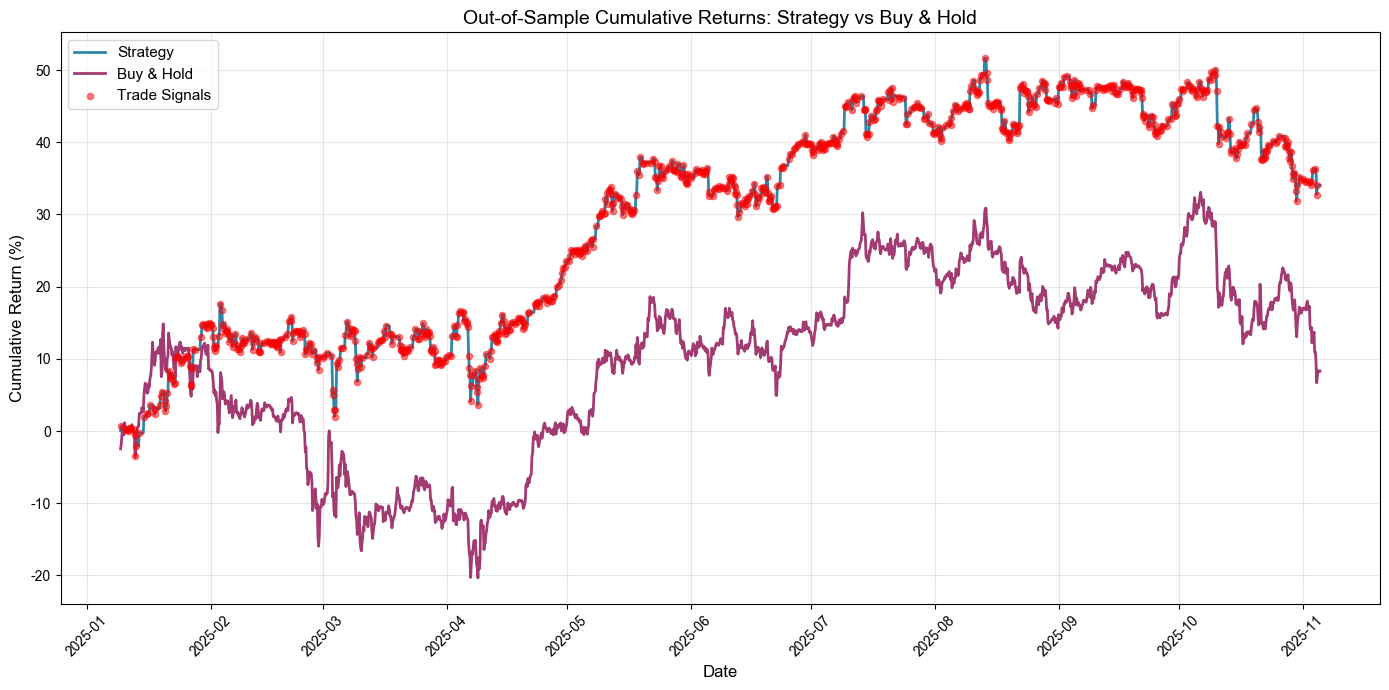

✓ Figure 1 saved: cumulative_returns.png

Generating Figure 2: Prediction probability distribution...


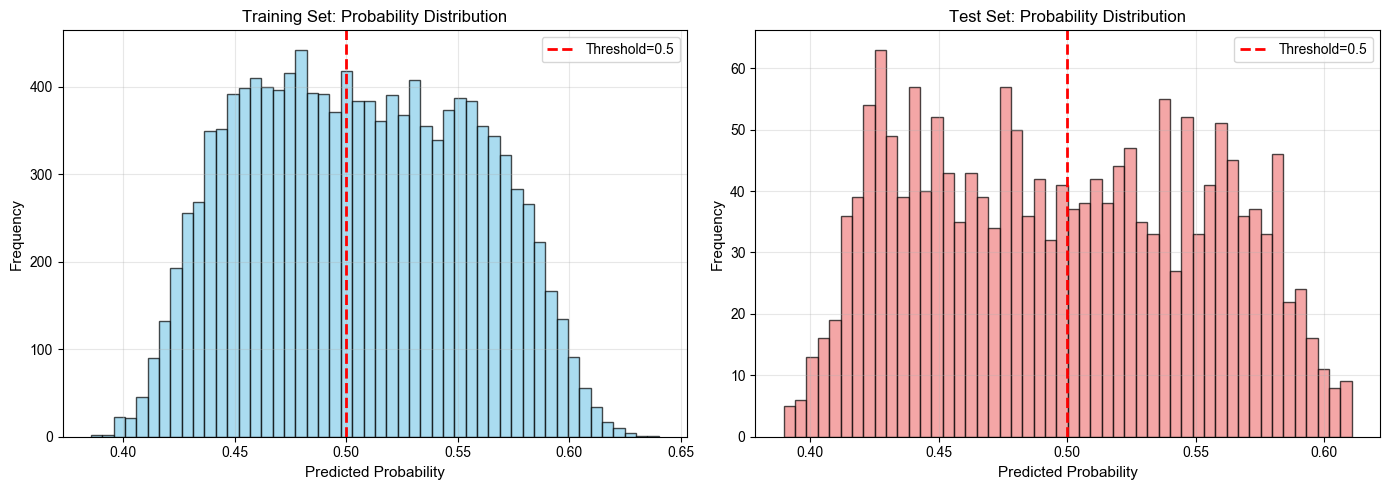

✓ Figure 2 saved: probability_distribution.png

Generating Figure 3: Monthly returns heatmap...


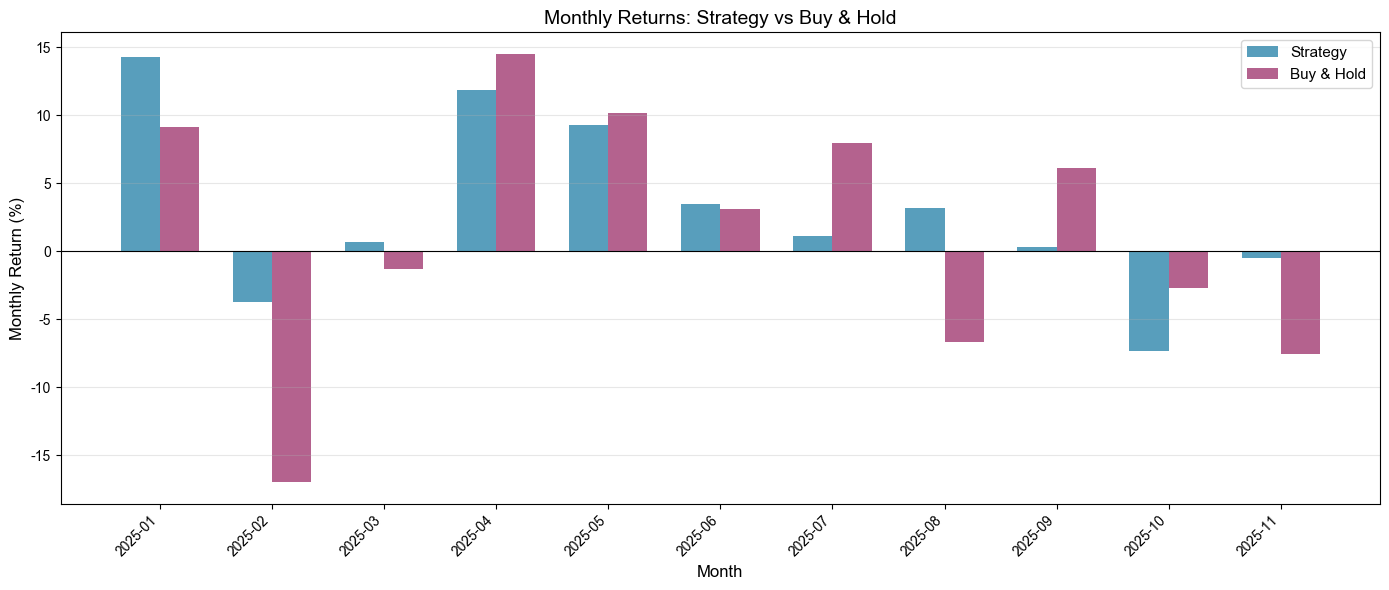

✓ Figure 3 saved: monthly_returns.png

Generating Figure 4: Feature importance...


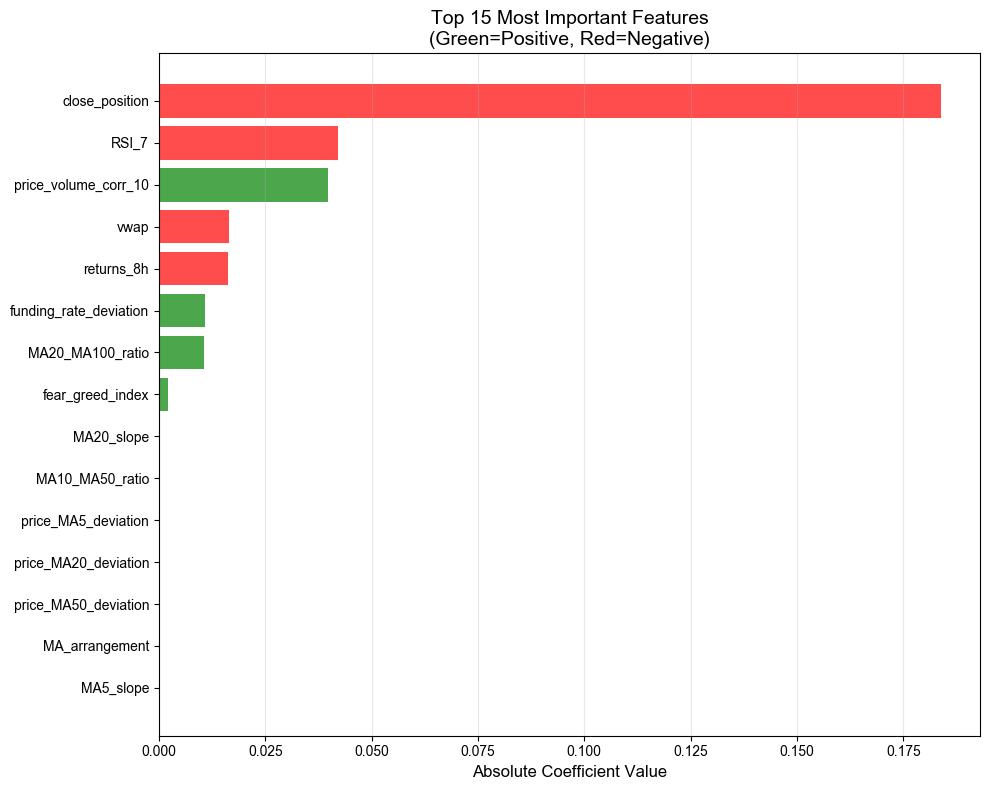

✓ Figure 4 saved: feature_importance.png

✓ All charts generated successfully!

Generating Figure 5: Equity curve ...


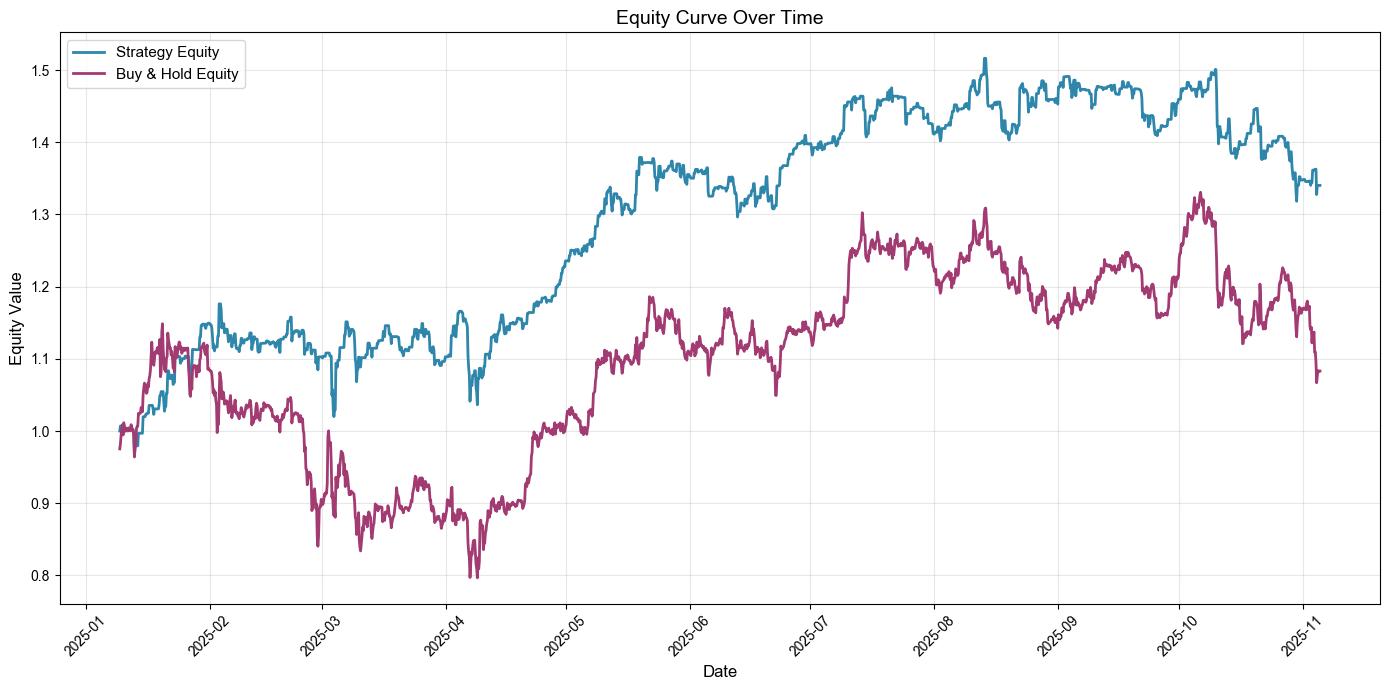

✓ Figure 5 saved: equity_curve.png


In [71]:
# ==========================================
# STEP 14: Visualization
# ==========================================
print("\n" + "="*60)
print("STEP 14: Visualization")
print("="*60)

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set font (if Chinese characters needed)
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# Figure 1: Cumulative Returns Comparison
# ==========================================
print("\nGenerating Figure 1: Cumulative returns comparison...")

fig, ax = plt.subplots(figsize=(14, 7))

# Calculate cumulative returns
strategy_cumulative = np.cumprod(1 + strategy_returns) - 1
buyhold_cumulative = np.cumprod(1 + test_actual_returns) - 1

# Get time index
test_dates = test_data['timestamp'].values

# Plot lines
ax.plot(test_dates, strategy_cumulative * 100, label='Strategy', linewidth=2, color='#2E86AB')
ax.plot(test_dates, buyhold_cumulative * 100, label='Buy & Hold', linewidth=2, color='#A23B72')

# Mark trade points
trade_dates = test_dates[test_signals == 1]
trade_returns = strategy_cumulative[test_signals == 1] * 100
ax.scatter(trade_dates, trade_returns, color='red', s=20, alpha=0.5, label='Trade Signals', zorder=5)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return (%)', fontsize=12)
ax.set_title('Out-of-Sample Cumulative Returns: Strategy vs Buy & Hold', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figs/cumulative_returns.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 1 saved: cumulative_returns.png")

# ==========================================
# Figure 2: Prediction Probability Distribution
# ==========================================
print("\nGenerating Figure 2: Prediction probability distribution...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
axes[0].hist(final_model.predict_proba(X_train_scaled)[:, 1], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].axvline(best_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold={best_threshold}')
axes[0].set_xlabel('Predicted Probability', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Training Set: Probability Distribution', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test set
axes[1].hist(y_test_proba, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1].axvline(best_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold={best_threshold}')
axes[1].set_xlabel('Predicted Probability', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Test Set: Probability Distribution', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figs/probability_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 2 saved: probability_distribution.png")

# ==========================================
# Figure 3: Monthly Returns Comparison
# ==========================================
print("\nGenerating Figure 3: Monthly returns heatmap...")

# Aggregate by month
test_data_with_returns = test_data.copy()
test_data_with_returns['strategy_return'] = strategy_returns
test_data_with_returns['buyhold_return'] = test_actual_returns
test_data_with_returns['year_month'] = test_data_with_returns['timestamp'].dt.to_period('M')

monthly_returns = test_data_with_returns.groupby('year_month').agg({
    'strategy_return': 'sum',
    'buyhold_return': 'sum'
})

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(monthly_returns))
width = 0.35

bars1 = ax.bar(x - width/2, monthly_returns['strategy_return'] * 100, width, 
               label='Strategy', color='#2E86AB', alpha=0.8)
bars2 = ax.bar(x + width/2, monthly_returns['buyhold_return'] * 100, width, 
               label='Buy & Hold', color='#A23B72', alpha=0.8)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Monthly Return (%)', fontsize=12)
ax.set_title('Monthly Returns: Strategy vs Buy & Hold', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([str(period) for period in monthly_returns.index], rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.savefig('figs/monthly_returns.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 3 saved: monthly_returns.png")

# ==========================================
# Figure 4: Feature Importance
# ==========================================
print("\nGenerating Figure 4: Feature importance...")

feature_importance = np.abs(final_model.coef_[0])
top_n = 15
top_indices = np.argsort(feature_importance)[-top_n:]

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['green' if final_model.coef_[0][i] > 0 else 'red' for i in top_indices]
ax.barh(range(top_n), feature_importance[top_indices], color=colors, alpha=0.7)
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_cols[i] for i in top_indices])
ax.set_xlabel('Absolute Coefficient Value', fontsize=12)
ax.set_title(f'Top {top_n} Most Important Features\n(Green=Positive, Red=Negative)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('figs/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 4 saved: feature_importance.png")

print("\n✓ All charts generated successfully!")

# ==========================================
# Figure 5: Equity Curve
# ==========================================
print("\nGenerating Figure 5: Equity curve ...")

fig, ax = plt.subplots(figsize=(14, 7))

# 计算净值（Equity Curve）
strategy_equity = np.cumprod(1 + strategy_returns)
buyhold_equity = np.cumprod(1 + test_actual_returns)

# 时间索引
test_dates = test_data['timestamp'].values

# 绘图
ax.plot(test_dates, strategy_equity, label='Strategy Equity', linewidth=2, color='#2E86AB')
ax.plot(test_dates, buyhold_equity, label='Buy & Hold Equity', linewidth=2, color='#A23B72')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Equity Value', fontsize=12)
ax.set_title('Equity Curve Over Time', fontsize=14, fontweight='bold')

ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('figs/equity_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 5 saved: equity_curve.png")